In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score


In [18]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().drop(columns="customerID")
print(df.shape)

(7032, 20)


Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


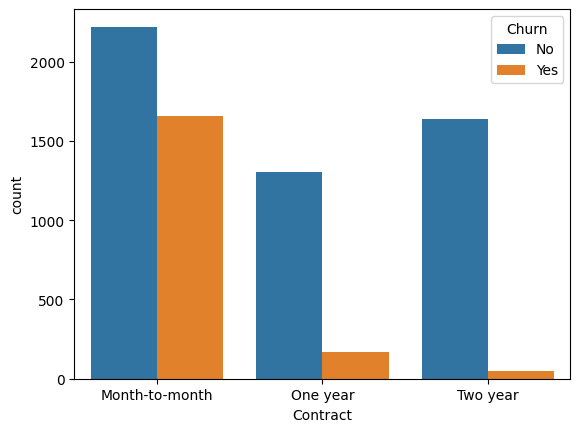

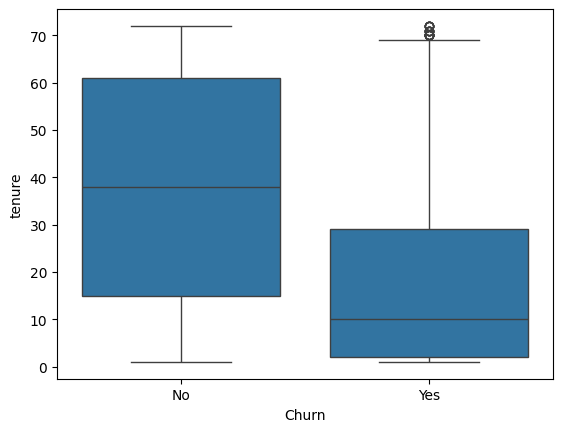

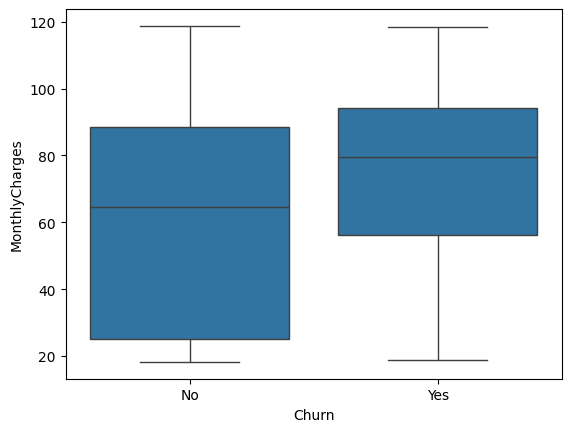

In [20]:
print(df["Churn"].value_counts(normalize=True))

sns.countplot(data=df, x="Contract", hue="Churn"); plt.show()
sns.boxplot(data=df, x="Churn", y="tenure"); plt.show()
sns.boxplot(data=df, x="Churn", y="MonthlyCharges"); plt.show()

In [21]:
print(df.shape)

(7032, 20)


In [22]:
y = (df["Churn"] == "Yes").astype(int)
X = pd.get_dummies(df.drop(columns="Churn"), drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


In [23]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_p = pca.fit_transform(X_train_s)
X_test_p = pca.transform(X_test_s)
print("Before:", X_train_s.shape[1], "After PCA:", X_train_p.shape[1])

Before: 30 After PCA: 17


In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}

for name, model in models.items():
    model.fit(X_train_p, y_train)
    pred = model.predict(X_test_p)
    prob = model.predict_proba(X_test_p)[:, 1]
    print(name,
          "| Acc:", round(accuracy_score(y_test, pred), 3),
          "| Recall:", round(recall_score(y_test, pred), 3),
          "| F1:", round(f1_score(y_test, pred), 3),
          "| AUC:", round(roc_auc_score(y_test, prob), 3))

Logistic Regression | Acc: 0.787 | Recall: 0.527 | F1: 0.569 | AUC: 0.83
Random Forest | Acc: 0.77 | Recall: 0.463 | F1: 0.516 | AUC: 0.799
XGBoost | Acc: 0.762 | Recall: 0.492 | F1: 0.523 | AUC: 0.804


In [25]:
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    print(name,
          "| Acc:", round(accuracy_score(y_test, pred), 3),
          "| Recall:", round(recall_score(y_test, pred), 3),
          "| F1:", round(f1_score(y_test, pred), 3),
          "| AUC:", round(roc_auc_score(y_test, prob), 3))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression | Acc: 0.803 | Recall: 0.572 | F1: 0.607 | AUC: 0.836
Random Forest | Acc: 0.79 | Recall: 0.519 | F1: 0.567 | AUC: 0.816
XGBoost | Acc: 0.771 | Recall: 0.527 | F1: 0.55 | AUC: 0.811
